In [1]:
import os
os.chdir('/workspaces/korea-real-estate-population-movement')

from src.config import DB_URL
import pandas as pd
from sqlalchemy import create_engine, inspect
import matplotlib.pyplot as plt

In [2]:
# Add Korean font
import matplotlib.font_manager as fm
fm.fontManager.addfont(
    "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
)
[f.name for f in fm.fontManager.ttflist if "Nanum" in f.name]
plt.rcParams["font.family"] = "NanumGothic"

In [7]:
engine = create_engine(DB_URL)

# Helper function to read sql file
def read_sql_file(path):
    with open(path,"r") as f:
        return f.read()


In [ ]:
# Inspect tables before calling data

inspector = inspect(engine)

for table in inspector.get_table_names():
    print(f"\n--- {table} ---")
    
    for column in inspector.get_columns(table):
        print(column["name"], column["type"])

In [ ]:
# Data Check
df = pd.read_sql(
    f"SELECT * FROM seoul_population_flow LIMIT 5",
    engine
)

display(df)


# Districts with the highest number of inflow and outflow

In [ ]:
cumulative_outflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_cumulative_outflow.sql')
yearly_top_outflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_outflow.sql')

top_outflow_districts = pd.read_sql_query(cumulative_outflow_query,engine)
yearly_outflow = pd.read_sql_query(yearly_top_outflow_query,engine)

display(top_outflow_districts)
display(yearly_outflow)

In [ ]:
cumulative_inflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_cumulative_inflow.sql')
yearly_top_inflow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_inflow.sql')

top_inflow_districts = pd.read_sql_query(cumulative_inflow_query,engine)
yearly_inflow = pd.read_sql_query(yearly_top_inflow_query,engine)

display(top_inflow_districts)
display(yearly_inflow)

## Observation

- After identifying districts with high inflow and outflow, we have decided to focus on the 7 districts that fall in that category: Gangnam, Songpa, Gangdong, Seocho, Gwanak, Dongjak, Yeongdeungpo. 

- Next, we are going to query the turnover rate of each of these districts over the last three years. 
    - Turnover = Inflow + Outflow

# Districts with the Highest Turnover

In [ ]:
yearly_turnover_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_turnover.sql')
yearly_turnover = pd.read_sql_query(yearly_turnover_query,engine)

display(yearly_turnover)

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3,figsize=(14,6))

district_colors = {
    "강남구": "tab:blue",
    "송파구": "tab:orange",
    "강동구": "tab:green",
    "서초구": "tab:red",
    "관악구": "tab:purple",
    "동작구": "tab:olive",
    "영등포구": "tab:pink"
}

for district in top_outflow_districts['from_district']:
    district_df = yearly_outflow[yearly_outflow['from_district'] == district]
    ax1.plot(
        district_df['year'],
        district_df['total_outflow'],
        marker="o",
        label=district,
        color=district_colors[district]
    )

ax1.set_xticks([2023, 2024, 2025])
ax1.set_xlabel("Year")
ax1.set_ylabel("Total Outflow")
ax1.set_title("People Moving Out")
ax1.legend()
ax1.grid(axis="y", alpha=0.3)

for district in top_inflow_districts['to_district']:
    district_df = yearly_inflow[yearly_inflow['to_district'] == district]

    ax2.plot(
        district_df['year'],
        district_df['total_inflow'],
        marker='o',
        label=district,
        color=district_colors[district]
    )

ax2.set_xticks([2023, 2024, 2025])
ax2.set_xlabel("Year")
ax2.set_ylabel("Total Inflow")
ax2.set_title("People Moving In")
ax2.legend()
ax2.grid(axis="y", alpha=0.3)

for district in yearly_turnover['district'].unique():
    district_df = yearly_turnover[yearly_turnover['district'] == district]

    ax3.plot(
        district_df['year'],
        district_df['turnover'],
        marker='o',
        label=district,
        color=district_colors[district]
    )

ax3.set_xticks([2023, 2024, 2025])
ax3.set_xlabel('Year')
ax3.set_ylabel('Total Turnover')
ax3.set_title('Total People Moving In & Out')
ax3.legend()
ax3.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

Outflow & Inflow Observations:

- Gangnam's net population movement has shifted from negative to positive.
    - Outflow: ~41K -> ~39K -> ~32K
    - Inflow: ~31K -> ~32K -> ~34K
- Gangdong has a huge increase in outflow over the three years
    - ~19K -> ~32K -> ~36K
    - Why did Gangdong record such large increases in resident outflow?
- Songpa is gaining population
    - While outflow stayed relatively steady, inflow is showing a increasing trend
        - Inflow: ~30K -> ~33K -> ~35K
- Gwanak's net population movement is becoming increasingly negative
    - Pairing a slow steady increase in outflow and decrease in inflow, Gwanak is slowly decreasing its overall net movement

Turnover Observations:
- Gangnam has the highest turnover with recently also recording a net positive population movement.
    - It has the highest amount of activity amongst the 7 districts.
- Songpa displays an increasing turnover trend over the last three years.
    - Songpa records the highest number of residents moving in while almost closing the gap with Gangnam for the highest turnover.
    - Songpa's population is growing in a city, creating a growing net positive population movement
- Gangdong, however, is the opposite. Although it has a increasing turnover trend in the observation period, Gangdong surpassed as the number 1 spot for highest residents moving out in 2025. 

 

# Individual Apartment Sales Data in Seoul

Individual Apartment Sales data holds every transaction of an apartment sale in Seoul. 

In [4]:
inspector = inspect(engine)

for column in inspector.get_columns('individual_apt_sales'):
    print(column["name"], column["type"])

id INTEGER
apt_name VARCHAR(50)
build_year INTEGER
deal_date INTEGER
floor INTEGER
district_code VARCHAR(5)
price_manwon INTEGER
size_m2 NUMERIC
unit VARCHAR(20)
dong VARCHAR(10)


In [ ]:
# Top 5 districts with the most transaction count
top_transaction_districts_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/top_five_transactions.sql')

top_transaction_districts = pd.read_sql(top_transaction_districts_query,engine)

display(top_transaction_districts)

,district,transaction_count
0,송파구,11905
1,노원구,11725
2,강동구,10003
3,강남구,9491
4,성북구,8728


## Observation on cumulative transaction count from 2023 - 2025

Observation:
- Songpa's interesting relationship
    - Highest apartment transaction volume
    - High Inflow
    - Stable Outflow
    - Increasing Turnover
- Nowon and Sungbook did not appear in our earlier observations. This may be a indication high apartment transaction activity doesn't necessarily correlate to a high population flow pattern.
- Gangdong
    - 3rd largest transaction volume
    - Sharp increase in outflow and turnover
    - Could Gangdong's high population movement be associated with its high housing transaction activity?
- Gangnam
    - Highest turnover amongst our 7 districts
    - Declining outflow
    - Increasing inflow
    - 4th highest transaction volume


## Transactions by Year of those 5 Districts

In [ ]:
yearly_top_transactions_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/yearly_top_transaction.sql')
yearly_top_transactions = pd.read_sql(yearly_top_transactions_query,engine)

display(yearly_top_transactions)

In [ ]:
district_colors = {
    "강남구": "tab:blue",
    "송파구": "tab:orange",
    "강동구": "tab:green",
    "서초구": "tab:red",
    "관악구": "tab:purple",
    "동작구": "tab:olive",
    "영등포구": "tab:pink",
    "성북구": "tab:brown",
    "노원구": "tab:gray"
}

fig, ax = plt.subplots(figsize=(10,6))

for district in yearly_top_transactions['district'].unique():
    district_df = yearly_top_transactions[yearly_top_transactions['district'] == district]

    ax.plot(
        district_df['deal_year'],
        district_df['transaction_count'],
        marker='o',
        label=district
    )

ax.set_xticks([2023, 2024, 2025])
ax.set_xlabel('Year')
ax.set_ylabel('Transaction Count')
ax.set_title('Apartment Sale Transaction Count')
ax.legend()
ax.grid(axis='y',alpha=0.3)

plt.tight_layout()
plt.show()

## Apartment Sale Transaction Observation

- Every district increased substantially over the 3 years
- Songpa and Nowon had the highest transaction activity with Nowon surpassing Songpa for the top spot.
- Gangdong had the sharpest increase in transaction count
    - Sharp increase in both Population Outflow and Apartment Transactions
- Gangnam by year 2025 had the lowest transaction count out of the 5 districts. 
    - Note: Gangnam had the highest population turnover 

In [ ]:
# Combine population flow and sale transaction df

yearly_top_transactions = yearly_top_transactions.rename(columns={"deal_year":"year"})

combined_df = yearly_top_transactions.merge(
    yearly_turnover,
    on=['district','year'],
    how='inner'
    )

for district in combined_df['district'].unique():
    display(combined_df[combined_df['district'] == district])



## Observations

- Songpa experienced increasing apartment transaction activity alongside increasing population inflow and turnover.
- Gangnam, on the other hand, recorded an increasing apartment transaction activity despite decreasing turnover. 
    - This suggest higher transaction activity did not correspond with increased population movement during the observation period.
- Gangdong experienced increasing apartment transaction activity alongside population outflow, and turnover. Because Gangdong's population inflow remained relatively steady, Gangdong's increased turnover is primarily driven by outflow. 
    - This raises the question, what could explain why Gangdong between 2023 and 2025 experienced simultaneous increase in apartment transactions and resident outflow?

# Hypothesis Testing

Does apartment transaction activity correlate with population movement
    - Transaction <-> Outflow
    - Transaction <-> Inflow
    - Transaction <-> Turnover

For this testing we will data monthly data from 2023 - 2025. 


## Transaction vs Outflow

H₀: There is no statistically significant relationship between monthly apartment transaction activity and monthly population outflow.

H₁: There is a statistically significant relationship between monthly apartment transaction activity and monthly population outflow.

In [8]:
monthly_transaction_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/monthly_transactions.sql')
monthly_population_flow_query = read_sql_file('/workspaces/korea-real-estate-population-movement/sql/analysis/monthly_population_flow.sql')

monthly_transaction = pd.read_sql(monthly_transaction_query,engine)
monthly_population_flow = pd.read_sql(monthly_population_flow_query,engine)

display(monthly_transaction)
display(monthly_population_flow)


,district,date,avg_price_m2,avg_build_age,avg_floor,transactions
0,송파구,202303,1934.67,21.69,12.94,232
1,강남구,202303,2412.72,27.42,8.70,183
2,강동구,202303,1316.86,16.84,9.96,178
3,송파구,202304,1848.28,22.77,11.68,281
4,강동구,202304,1314.55,18.19,11.47,226
...,...,...,...,...,...,...
97,강남구,202511,3127.48,23.33,9.29,266
98,강동구,202511,1544.93,21.25,9.95,110
99,송파구,202512,2316.73,26.62,9.40,311
100,강동구,202512,1541.59,21.60,9.82,213


,district,date,inflow,outflow,turnover
0,강남구,202301,2420,2306,4726
1,강동구,202301,1091,1337,2428
2,송파구,202301,2020,2340,4360
3,송파구,202302,2969,3455,6424
4,강남구,202302,3272,3849,7121
...,...,...,...,...,...
103,강남구,202511,2331,2287,4618
104,송파구,202511,2180,1790,3970
105,강남구,202512,2944,2992,5936
106,송파구,202512,2837,2535,5372


In [9]:
combined_df = monthly_transaction.merge(
    monthly_population_flow,
    on=['district','date'],
    how='inner'
)

display(combined_df)

,district,date,avg_price_m2,avg_build_age,avg_floor,transactions,inflow,outflow,turnover
0,송파구,202303,1934.67,21.69,12.94,232,3170,2804,5974
1,강남구,202303,2412.72,27.42,8.70,183,2722,4504,7226
2,강동구,202303,1316.86,16.84,9.96,178,1508,1605,3113
3,송파구,202304,1848.28,22.77,11.68,281,2380,2406,4786
4,강동구,202304,1314.55,18.19,11.47,226,1276,1280,2556
...,...,...,...,...,...,...,...,...,...
97,강남구,202511,3127.48,23.33,9.29,266,2331,2287,4618
98,강동구,202511,1544.93,21.25,9.95,110,1293,1526,2819
99,송파구,202512,2316.73,26.62,9.40,311,2837,2535,5372
100,강동구,202512,1541.59,21.60,9.82,213,1693,1935,3628


In [ ]:
# Scatter plot of transactions vs Inflow, Outflow, and Turnover

fig, (ax1, ax2, ax3) = plt.subplots(1,3,figsize=(10,6))

gangnam = combined_df[combined_df['district'] == '강남구']
gangdong = combined_df[combined_df['district'] == '강동구']
songpa = combined_df[combined_df['district'] == '송파구']

ax1.scatter(
    gangnam['transactions'],
    gangnam['outflow']
)

ax1.set_xlabel('Apartment Transactions')
ax1.set_ylabel('Population Outflow')
ax1.set_title("Transactions vs Outflow — Gangnam")
ax1.grid(alpha=0.3)

ax2.scatter(
    gangdong['transactions'],
    gangdong['outflow']
)

ax2.set_xlabel('Apartment Transactions')
ax2.set_ylabel('Population Outflow')
ax2.set_title("Transactions vs Outflow — Gangdong")
ax2.grid(alpha=0.3)

ax3.scatter(
    songpa['transactions'],
    songpa['outflow']
)

ax3.set_xlabel('Apartment Transactions')
ax3.set_ylabel('Population Outflow')
ax3.set_title("Transactions vs Outflow — Songpa")
ax3.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [12]:
# Correlation of each district 
print('Outflow')
for district in combined_df['district'].unique():
    district_df = combined_df[combined_df['district'] == district]

    correlation = district_df['transactions'].corr(
        district_df['outflow']
    )

    print(district, correlation)

print('\nInflow')
for district in combined_df['district'].unique():
    district_df = combined_df[combined_df['district'] == district]

    correlation = district_df['transactions'].corr(
        district_df['inflow']
    )

    print(district, correlation)

print('\nTurnover')
for district in combined_df['district'].unique():
    district_df = combined_df[combined_df['district'] == district]

    correlation = district_df['transactions'].corr(
        district_df['turnover']
    )

    print(district, correlation)

Outflow
송파구 0.08607296299137256
강남구 -0.16890638837745547
강동구 0.024239212481973325

Inflow
송파구 0.14896719330491562
강남구 0.13150057926086095
강동구 -0.07939762057610676

Turnover
송파구 0.13338352817916135
강남구 -0.09325934344322975
강동구 0.015125309773808632


## Observations

- Correlation
    - Songpa: r = 0.086, 0.148, 0.133
        - Very weak relationship (Almost 0)
    - Gangdong: r = 0.024, -0.079, 0.015
        - Also practically 0
    - Gangnam: r = -0.168, 0.132, -0.093
        - A weak negative relationship in outflow and turnover

In [ ]:
from scipy.stats import pearsonr

print('Outflow ~ Transaction Correlation & P-value')
for district in combined_df["district"].unique():
    district_df = combined_df[combined_df["district"] == district]

    r, p = pearsonr(
        district_df["transactions"],
        district_df["outflow"]
    )

    print(district)
    print('r:', r)
    print('p-value:', p,'\n')

print('Inflow ~ Transaction Correlation & P-value')
for district in combined_df["district"].unique():
    district_df = combined_df[combined_df["district"] == district]

    r, p = pearsonr(
        district_df["transactions"],
        district_df["inflow"]
    )

    print(district)
    print('r:', r)
    print('p-value:', p, '\n')

print('Turnover ~ Transaction Correlation & P-value')
for district in combined_df["district"].unique():
    district_df = combined_df[combined_df["district"] == district]

    r, p = pearsonr(
        district_df["transactions"],
        district_df["turnover"]
    )
    
    print(district)
    print('r:', r)
    print('p-value:', p)

outflow
송파구
r: 0.08607296299137254
p-value: 0.628375579665057 

강남구
r: -0.1689063883774554
p-value: 0.33961258262190624 

강동구
r: 0.02423921248197331
p-value: 0.8917652718035713 

inflow
송파구
r: 0.14896719330491567
p-value: 0.4004394306146989 

강남구
r: 0.131500579260861
p-value: 0.45849867247503484 

강동구
r: -0.0793976205761068
p-value: 0.655342492176465 

turnover
송파구
r: 0.13338352817916133
p-value: 0.45203205091509663
강남구
r: -0.09325934344322971
p-value: 0.5998638668966899
강동구
r: 0.01512530977380864
p-value: 0.9323402530494868


**Transactions vs Outflow**

| District | r | p-value |
|---|---:|---:|
| 송파구 | 0.086 | 0.628 |
| 강남구 | -0.169 | 0.340 |
| 강동구 | 0.024 | 0.892 |

**Transactions vs Inflow**

| District | r | p-value |
|---|---:|---:|
| 송파구 | 0.149 | 0.400 |
| 강남구 | 0.132 | 0.458 |
| 강동구 | -0.079 | 0.655 |

**Transactions vs Turnover**
| District | r | p-value |
|---|---:|---:|
| 송파구 | 0.133 | 0.452 |
| 강남구 | -0.093 | 0.600 |
| 강동구 | 0.015 | 0.932 |

## Transaction vs Outflow, Inflow, and Turnover

- At the 0.05 significance threshold, none of the tested relationships were statistically significant.
- Hence, we fail to reject the null hypothesis that there is no statistically significant linear relationship between apartment transaction and outflow. 
- These results suggest that the observed changes in apartment transaction activity do not, by themselves, provide strong evidence for a linear relationship with monthly population movement.

# Linear Regression

## Linear Regression: Outflow ~ Transactions + Transaction Variables

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor

In [15]:
# Independent Variables
X = combined_df[
    [
        'transactions',
        'avg_price_m2',
        'avg_build_age',
        'avg_floor'
    ]
]

#Dependent Variable
y = combined_df['outflow']

In [16]:
# Split into 80/20 train/test set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ -0.16, 0.48,-21.92, 89.44]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['transactions','avg_price_m2','avg_build_age','avg_floor']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1355
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [18]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, coefficient)

y_pred = model.predict(X_test)

Intercept: 1355.1497664157578
transactions -0.15611779435864268
avg_price_m2 0.4755133615529811
avg_build_age -21.918643846493083
avg_floor 89.4439781848914


In [19]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 627.9447798221197
RMSE: 808.2059130063769
R²: -0.015591415736484038


## Observations

- This initial regression showed little to no explanatory and predictive performance. The R^2 of -0.016 indicates that it performs slightly worse than a baseline model. 
- On average, the model was approximately off by 628 people (MAE), and approximately RMSE of 808 people indicates that larger prediction errors have a greater effect on the overall error metric.

## Linear Regression: Outflow ~ Transactions + Transaction Variables + District2 + District3

In [20]:
# Turning each district into a column with the first as the baseline
X = pd.get_dummies(
    combined_df[
        [
            "district",
            "transactions",
            "avg_price_m2",
            "avg_build_age",
            "avg_floor"
        ]
    ],
    columns=["district"],
    drop_first=True
)

y = combined_df['outflow']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [23]:
# Calculates the baseline with the mean of outflow
dummy = DummyRegressor(strategy="mean")
dummy.fit(X_train, y_train)

dummy_pred = dummy.predict(X_test)

print(r2_score(y_test, dummy_pred))

-0.05808958367746331


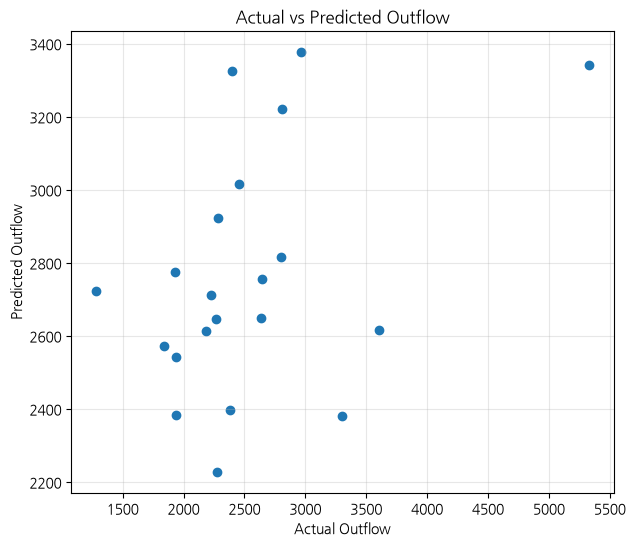

In [24]:
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Outflow")
plt.ylabel("Predicted Outflow")
plt.title("Actual vs Predicted Outflow")

plt.grid(alpha=0.3)
plt.show()

In [25]:
print("Intercept:", model.intercept_)

for feature, coefficient in zip(X.columns, model.coef_):
    print(feature, coefficient)

Intercept: 3364.598095004253
transactions 0.449475946378365
avg_price_m2 -0.6203858967328255
avg_build_age 6.957935575378732
avg_floor 131.0928097850782
district_강동구 -1557.7467652735436
district_송파구 -1298.413286988946


In [26]:
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 592.1807726139432
RMSE: 761.969516572548
R²: 0.09728601878931231


## Observations for regression on Outflow with districts

| Model            | MAE | RMSE |        R² |
| ---------------- | --: | ---: | --------: |
| Without district | 628 |  808 |**-0.016** |
| With district    | 592 |  762 | **0.097** |


- Adding district as a categorical variable improved the model's predictive performance.
  - R² increased from -0.016 to 0.097.
  - MAE decreased from approximately 628 to 592.
  - RMSE decreased from approximately 808 to 762.

- The model with district information performed better than both the model without district information and the mean baseline.
  - This suggests that district-specific differences contain useful information for explaining variation in population outflow.

- Nevertheless, the R² of 0.097 remains relatively low.
  - This model explains around 9.7% of the variation in the monthly population outflow test set.

## Linear Regression for Inflow and Turnover

In [30]:
# Inflow
X_i = pd.get_dummies(
    combined_df[
        [
            "district",
            "transactions",
            "avg_price_m2",
            "avg_build_age",
            "avg_floor"
        ]
    ],
    columns=["district"],
    drop_first=True
)

y_i = combined_df['inflow']

# Turnover
X_t = pd.get_dummies(
    combined_df[
        [
            "district",
            "transactions",
            "avg_price_m2",
            "avg_build_age",
            "avg_floor"
        ]
    ],
    columns=["district"],
    drop_first=True
)

y_t = combined_df['turnover']

In [31]:
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_i,
    y_i,
    test_size=0.2,
    random_state=42
)

model_i = LinearRegression()

In [ ]:
# Fit model for Inflow ~ 
model_i.fit(X_train_i, y_train_i)

y_pred_i = model_i.predict(X_test_i)

In [33]:
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_t,
    y_t,
    test_size=0.2,
    random_state=42
)

model_t = LinearRegression()

In [34]:
# Fit model for Turnover ~
model_t.fit(X_train_t, y_train_t)

y_pred_t = model_t.predict(X_test_t)

In [35]:
# Dummy regressor for Inflow
dummy_i = DummyRegressor(strategy="mean")
dummy_i.fit(X_train_i, y_train_i)

dummy_pred_i = dummy_i.predict(X_test_i)

print('Inflow model R²: ', r2_score(y_test_i, y_pred_i))
print('Inflow dummy R²: ', r2_score(y_test_i, dummy_pred_i),'\n')

# Dummy regressor for Turnover
dummy_t = DummyRegressor(strategy="mean")
dummy_t.fit(X_train_t, y_train_t)

dummy_pred_t = dummy_t.predict(X_test_t)

print('Turnover model R²: ', r2_score(y_test_t, y_pred_t))
print('Turnover dummy R²: ', r2_score(y_test_t, dummy_pred_t))

Inflow model R²:  0.553092665819362
Inflow dummy R²:  -0.0020307067744935736 

Turnover model R²:  0.2835236189262438
Turnover dummy R²:  -0.01756951512054239


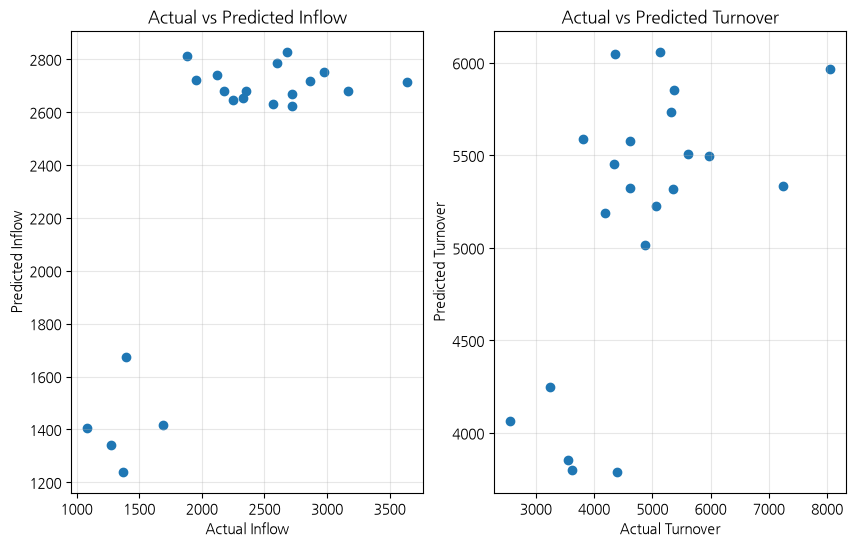

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,6))


ax1.scatter(y_test_i, y_pred_i)

ax1.set_xlabel("Actual Inflow")
ax1.set_ylabel("Predicted Inflow")
ax1.set_title("Actual vs Predicted Inflow")
ax1.grid(alpha=0.3)

ax2.scatter(y_test_t, y_pred_t)
ax2.set_xlabel("Actual Turnover")
ax2.set_ylabel("Predicted Turnover")
ax2.set_title("Actual vs Predicted Turnover")

ax2.grid(alpha=0.3)
plt.show()

In [47]:
print('----Inflow----\n\n', 'Intercept:', model_i.intercept_)

for feature, coefficient in zip(X_i.columns, model_i.coef_):
    print(feature, coefficient)

----Inflow----

 Intercept: 760.3737370733818
transactions 0.3804160415765708
avg_price_m2 0.23580375195441006
avg_build_age 28.520053250325866
avg_floor 41.82445780464857
district_강동구 -814.2657026306564
district_송파구 215.0388482122111


In [ ]:
print('----Turnover----\n\n', 'Intercept:', model_t.intercept_)

for feature, coefficient in zip(X_t.columns, model_t.coef_):
    print(feature, coefficient)

----Tunover----

 Intercept: 4124.971832077634
transactions 0.8298919879549357
avg_price_m2 -0.38458214477841546
avg_build_age 35.47798882570463
avg_floor 172.9172675897268
district_강동구 -2372.012467904201
district_송파구 -1083.3744387767358


In [49]:
mae_i = mean_absolute_error(y_test_i, y_pred_i)
rmse_i = mean_squared_error(y_test_i, y_pred_i) ** 0.5
r2_i = r2_score(y_test_i, y_pred_i)

print('Inflow')
print("MAE:", mae_i)
print("RMSE:", rmse_i)
print("R²:", r2_i)

Inflow
MAE: 346.4733887078073
RMSE: 435.41921542494214
R²: 0.553092665819362


In [51]:
mae_t = mean_absolute_error(y_test_t, y_pred_t)
rmse_t = mean_squared_error(y_test_t, y_pred_t) ** 0.5
r2_t = r2_score(y_test_t, y_pred_t)

print('Turnover')
print("MAE:", mae_t)
print("RMSE:", rmse_t)
print("R²:", r2_t)

Turnover
MAE: 837.291556174388
RMSE: 1046.9021104103686
R²: 0.2835236189262438



| Target       |   MAE |  RMSE |         R²|
| ------------ | ----: | ----: | ---------:|
| **Outflow**  |   628 |   808 | **-0.015**|
| **Inflow**   |   346 |   435 | **0.553** |
| **Turnover** |   837 | 1,046 | **0.283** |



## Regression Model Comparison — Observations

- The regression models performed differently depending on the population movement measure being predicted.

- **Inflow had the strongest predictive performance**, with an R² of 0.553.
  - The model explained approximately 55.3% of the variation in monthly population inflow in the test set.
  - This suggests that the selected transaction and housing variables, along with district information, contain useful information for predicting inflow.

- **Turnover showed moderate but limited predictive performance**, with an R² of 0.283.
  - The model explained approximately 28.3% of the variation in monthly turnover.
  - A substantial portion of turnover variation remains unexplained.

- **Outflow had the weakest predictive performance**, with an R² of -0.015.
  - The model performed slightly worse than the mean baseline.
  - This suggests that the selected variables provide very limited predictive information about population outflow.

- Overall, the models were substantially better at predicting **inflow than outflow**.
  - This suggests that the factors associated with people moving into a district may differ from those associated with people moving out.

- These results also reinforce the earlier correlation analysis: **Monthly apartment transaction activity did not show a strong linear relationship with population inflow, outflow, or turnover in the districts examined.** However, the multivariable regression showed substantially stronger predictive performance for inflow when transaction and housing characteristics and district information were considered together.